In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt

In [14]:
data = {
    'luas_tanah': [
        60, 65, 70, 75, 80, 85, 90, 95, 100, 105,
        110, 115, 120, 125, 130, 135, 140, 145, 150, 155,
        160, 170, 180, 190, 200, 210, 220, 230, 240, 250
    ],
    'jumlah_kamar': [
        2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
        3, 3, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 5, 5, 5, 5, 5, 5, 6, 6, 6
    ],
    'harga_rumah': [
        300, 315, 340, 355, 410, 425, 440, 460, 485, 500,
        515, 530, 610, 625, 645, 660, 680, 700, 720, 745,
        770, 850, 890, 930, 970, 1020, 1080, 1150, 1210, 1280
    ]
}
df = pd.DataFrame(data)
print(df)

    luas_tanah  jumlah_kamar  harga_rumah
0           60             2          300
1           65             2          315
2           70             2          340
3           75             2          355
4           80             3          410
5           85             3          425
6           90             3          440
7           95             3          460
8          100             3          485
9          105             3          500
10         110             3          515
11         115             3          530
12         120             4          610
13         125             4          625
14         130             4          645
15         135             4          660
16         140             4          680
17         145             4          700
18         150             4          720
19         155             4          745
20         160             4          770
21         170             5          850
22         180             5      

Dalam model ini, kita melihat bahwa harga rumah tidak hanya dipengaruhi oleh satu faktor tunggal. Meskipun 'Luas Tanah' menjadi kontributor utama terhadap kenaikan harga, variabel 'Jumlah Kamar' memberikan dimensi tambahan yang membuat prediksi lebih akurat. Penggunaan Regresi Berganda memungkinkan kita untuk melihat bobot (koefisien) dari masing-masing faktor. Misalnya, kita bisa mengetahui apakah menambah satu kamar lebih bernilai daripada menambah 10 meter persegi luas tanah.

In [15]:
# Menentukan variabel
x = df[['luas_tanah', 'jumlah_kamar']]
y = df['harga_rumah']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit (x_train, y_train)

LinearRegression()

In [16]:
print("Intercept (a):", model.intercept_)
print("koefisien (b1,b2,b3):", model.coef_)


Intercept (a): -42.65683904732305
koefisien (b1,b2,b3): [ 4.43937664 28.36283652]


In [17]:
y_pred = model.predict(x_test)

print("Prediksi:", y_pred)
print("Harga asli:", y_test.values)


Prediksi: [1148.57680623  670.11035282  942.63890429  714.50411917  486.36933406
  508.56621724]
Harga asli: [1150  660  930  700  485  500]


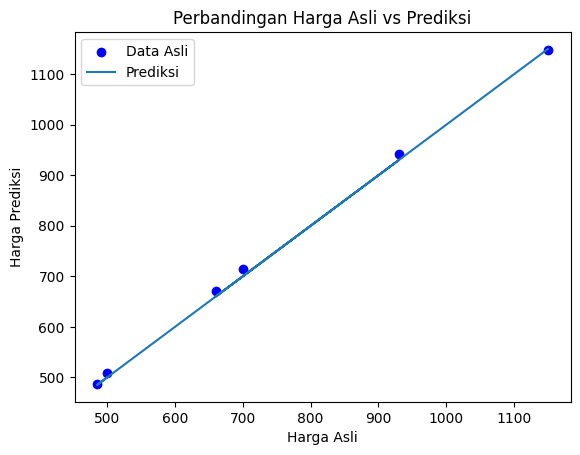

In [18]:
plt.scatter(y_test, y_pred, color ='blue', label='Data Asli')
plt.plot(y_test, y_test, label='Prediksi')
plt.xlabel("Harga Asli")
plt.ylabel("Harga Prediksi")
plt.title("Perbandingan Harga Asli vs Prediksi")
plt.legend()
plt.show()

In [19]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 8.10202022442015
MSE: 91.6018737877854
RMSE: 9.57088678168253


In [22]:
data_baru = [[20, 96]]
prediksi = model.predict(data_baru)

print("Prediksi harga rumah:", prediksi[0])

Prediksi harga rumah: 2768.9629995121304


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
